In [63]:
import random
import warnings
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
import albumentations as A
from glob import glob
import pandas as pd
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau
from segmentation_models_pytorch.losses import FocalLoss


In [64]:
# Игнорировать предупреждения libpng
warnings.filterwarnings("ignore", message=".*iCCP.*")

encoder = "resnet50"
enc_weights = "imagenet"
rare_classes = [3, 6, 8, 11, 15, 18, 22]
num_epochs = 50
patience = 20
image_size = 512
batch_size = 4
device = torch.device("mps")
class_dict = pd.read_csv("/Users/xd/Desktop/nsu_2course/2_sem/AI/labs/lab_2/CamVid/class_dict.csv")
NUM_CLASSES = len(class_dict)

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

In [65]:
print(f"Device: {device}")
print(f"Number of classes: {NUM_CLASSES}")
print(class_dict)

Device: mps
Number of classes: 32
                 name    r    g    b
0              Animal   64  128   64
1             Archway  192    0  128
2           Bicyclist    0  128  192
3              Bridge    0  128   64
4            Building  128    0    0
5                 Car   64    0  128
6     CartLuggagePram   64    0  192
7               Child  192  128   64
8         Column_Pole  192  192  128
9               Fence   64   64  128
10       LaneMkgsDriv  128    0  192
11    LaneMkgsNonDriv  192    0   64
12          Misc_Text  128  128   64
13  MotorcycleScooter  192    0  192
14        OtherMoving  128   64   64
15       ParkingBlock   64  192  128
16         Pedestrian   64   64    0
17               Road  128   64  128
18       RoadShoulder  128  128  192
19           Sidewalk    0    0  192
20         SignSymbol  192  128  128
21                Sky  128  128  128
22     SUVPickupTruck   64  128  192
23        TrafficCone    0    0   64
24       TrafficLight    0   64   64
25  

In [ ]:
def rgb_to_index(mask, class_dict):
    mask_ind = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.uint8)
    for i, row in class_dict.iterrows():    # номер класса + его rgb
        rgb = np.array([row['r'], row['g'], row['b']])  
        """
        np.all(mask == rgb, axis=-1) ---- булевая матрица H*W
        беру каждый пиксель равный rgb и пишу ему его класс(i)
        """
        mask_ind[np.all(mask == rgb, axis=-1)] = i
    return mask_ind

# для визуализации
def index_to_rgb(index_mask, class_dict):
    rgb_mask = np.zeros((index_mask.shape[0], index_mask.shape[1], 3), dtype=np.uint8)
    for i, row in class_dict.iterrows():
        rgb_mask[index_mask == i] = [row["r"], row["g"], row["b"]]
    return rgb_mask

# Визуализация

### отображение масок для всех классов

In [ ]:
def visualize_all_classes(class_dict, patch_size=50, cols=6):

    num_classes = NUM_CLASSES
    rows = 6  

    plt.figure(figsize=(cols * 2, rows * 2))

    # по всем классам
    for i in range(num_classes):
        class_name = class_dict.iloc[i]["name"]  # название класса
        rgb = class_dict.iloc[i][["r", "g", "b"]].values.astype(np.uint8)  # rgb

        # заполнение патча
        patch = np.zeros((patch_size, patch_size, 3), dtype=np.uint8)
        patch[:, :] = rgb  # Заполняем патч цветом класса

        # отображение патча в сетке
        plt.subplot(rows, cols, i + 1)
        plt.imshow(patch)
        plt.title(class_name, fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

### тестовое отображение пары: фото + маска (train_dataset)

In [ ]:
def test_output(dataset):
    img, mask = dataset[0]
    img = img.cpu().permute(1, 2, 0).numpy()  # (C, H, W) -> (H, W, C)
    img_denorm = img * std + mean  # денормализация
    img_denorm = np.clip(img_denorm, 0, 1)  # ограничение значений: [0,1]

    mask_rgb = index_to_rgb(mask.numpy(), class_dict)


    # Визуализация
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.title("Image")
    plt.imshow(img_denorm)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Mask (colored)")
    plt.imshow(mask_rgb)
    plt.axis("off")

    plt.show()

### отображение тройки изображений: фото + реальная маска + предсказанная маска

In [ ]:
def visualize_triplet(img, true_mask, pred_mask, class_dict, mean, std):
    img = img.cpu().permute(1, 2, 0).numpy()    # (C, H, W) -> (H, W, C)
    img_denorm = img * std + mean  # денормализация
    img_denorm = np.clip(img_denorm, 0, 1)  # ограничение значений: [0,1]

    # Преобразование масок в RGB
    true_mask_rgb = index_to_rgb(true_mask.numpy(), class_dict)  # Истинная маска
    pred_mask_rgb = index_to_rgb(pred_mask.numpy(), class_dict)  # Предсказанная маска

    return img_denorm, true_mask_rgb, pred_mask_rgb

# Metrics func

### Pixel accuracy:
pa = правильно классифицировнные пиксели / общее кол-во пикселей

### Dice
dc = 2⋅Intersection / (Prediction + Target)​

In [70]:
def compute_iou(pred, target, num_classes, ignore_classes=None):
    if ignore_classes is None:
        ignore_classes = []
    pred = pred.argmax(dim=1).cpu().numpy()
    target = target.cpu().numpy()
    ious = []
    for cls in range(num_classes):
        if cls in ignore_classes:
            continue  # Пропускаем класс Void
        pred_cls = pred == cls
        target_cls = target == cls
        intersection = np.logical_and(pred_cls, target_cls).sum()
        union = np.logical_or(pred_cls, target_cls).sum()
        iou = intersection / (union + 1e-6) if union > 0 else 1.0
        ious.append(iou)
    return np.mean(ious), ious

In [71]:
def compute_pixel_accuracy(pred, target):
    pred = pred.argmax(dim=1).cpu().numpy()  # Предсказанные классы
    target = target.cpu().numpy()  # Истинные классы
    correct = (pred == target).sum()  # Количество совпадающих пикселей
    total = target.size  # Общее количество пикселей
    return correct / total

In [72]:
def compute_dice(pred, target, num_classes, ignore_classes=None):
    if ignore_classes is None:
        ignore_classes = []
    pred = pred.argmax(dim=1).cpu().numpy()
    target = target.cpu().numpy()
    dices = []
    for cls in range(num_classes):
        if cls in ignore_classes:
            continue
        pred_cls = pred == cls
        target_cls = target == cls
        intersection = np.logical_and(pred_cls, target_cls).sum()
        pred_sum = pred_cls.sum()
        target_sum = target_cls.sum()
        dice = (2 * intersection) / (pred_sum + target_sum + 1e-6) if (pred_sum + target_sum) > 0 else 1.0
        dices.append(dice)
    return np.mean(dices), dices

# Аугментация

In [73]:
train_transform = A.Compose([
    A.Resize(height=image_size, width=image_size),  # Установка размера
    A.HorizontalFlip(p=0.5),  # Горизонтальное отражение
    A.RandomRotate90(p=0.5),  # Поворот на 90 градусов
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),  # Сдвиги, масштабирование, повороты
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),  # Яркость и контраст
    A.HueSaturationValue(p=0.2),  # Изменение оттенка, насыщенности и яркости
    A.GaussNoise(p=0.2),  # Гауссовский шум
    A.Blur(blur_limit=3, p=0.1),  # Размытие
    A.Normalize(mean=mean, std=std),  # Нормализация (ImageNet)
])

val_transform = A.Compose([
    A.Resize(height=image_size, width=image_size),
    A.Normalize(mean=mean, std=std),  # Только нормализация
])


/Users/xd/Desktop/nsu_2course/2_sem/AI/venv/lib/python3.13/site-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


# Датасет

In [ ]:
# glob - поиск всех файлов по шаблонному пути
class CamVidDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None, class_dict=None):
        self.image_paths = sorted(glob(image_paths))
        self.mask_paths = sorted(glob(mask_paths))
        self.transform = transform
        self.class_dict = class_dict

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_paths[idx])
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        if self.class_dict is not None:
            mask = rgb_to_index(mask, self.class_dict)
        else:
            mask = mask[:, :, 0]

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented["image"], augmented["mask"]

        img = img.transpose((2, 0, 1)).astype(np.float32)   # (H,W,C) -> (C,H,W) для торча
        img = torch.tensor(img)     # img -> float32
        mask = torch.tensor(mask, dtype=torch.long) # для лосс ф-ии
        return img, mask

In [ ]:
train_dataset = CamVidDataset(
    image_paths="/Users/xd/Desktop/nsu_2course/2_sem/AI/labs/lab_2/CamVid/train/*.png",
    mask_paths="/Users/xd/Desktop/nsu_2course/2_sem/AI/labs/lab_2/CamVid/train_labels/*.png",
    transform=train_transform,
    class_dict=class_dict
)
val_dataset = CamVidDataset(
    image_paths="/Users/xd/Desktop/nsu_2course/2_sem/AI/labs/lab_2/CamVid/val/*.png",
    mask_paths="/Users/xd/Desktop/nsu_2course/2_sem/AI/labs/lab_2/CamVid/val_labels/*.png",
    transform=val_transform,
    class_dict=class_dict
)
test_dataset = CamVidDataset(
    image_paths="/Users/xd/Desktop/nsu_2course/2_sem/AI/labs/lab_2/CamVid/test/*.png",
    mask_paths="/Users/xd/Desktop/nsu_2course/2_sem/AI/labs/lab_2/CamVid/test_labels/*.png",
    transform=val_transform,
    class_dict=class_dict
)

In [76]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, drop_last=True)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 369
Val dataset size: 100
Test dataset size: 232


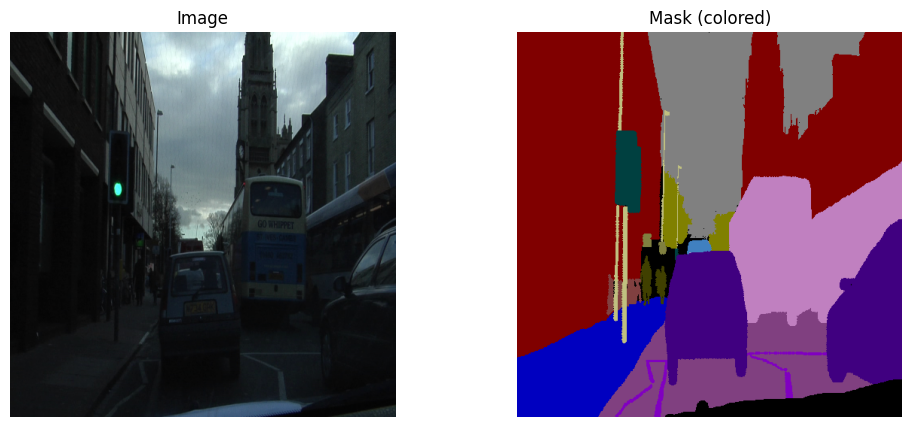

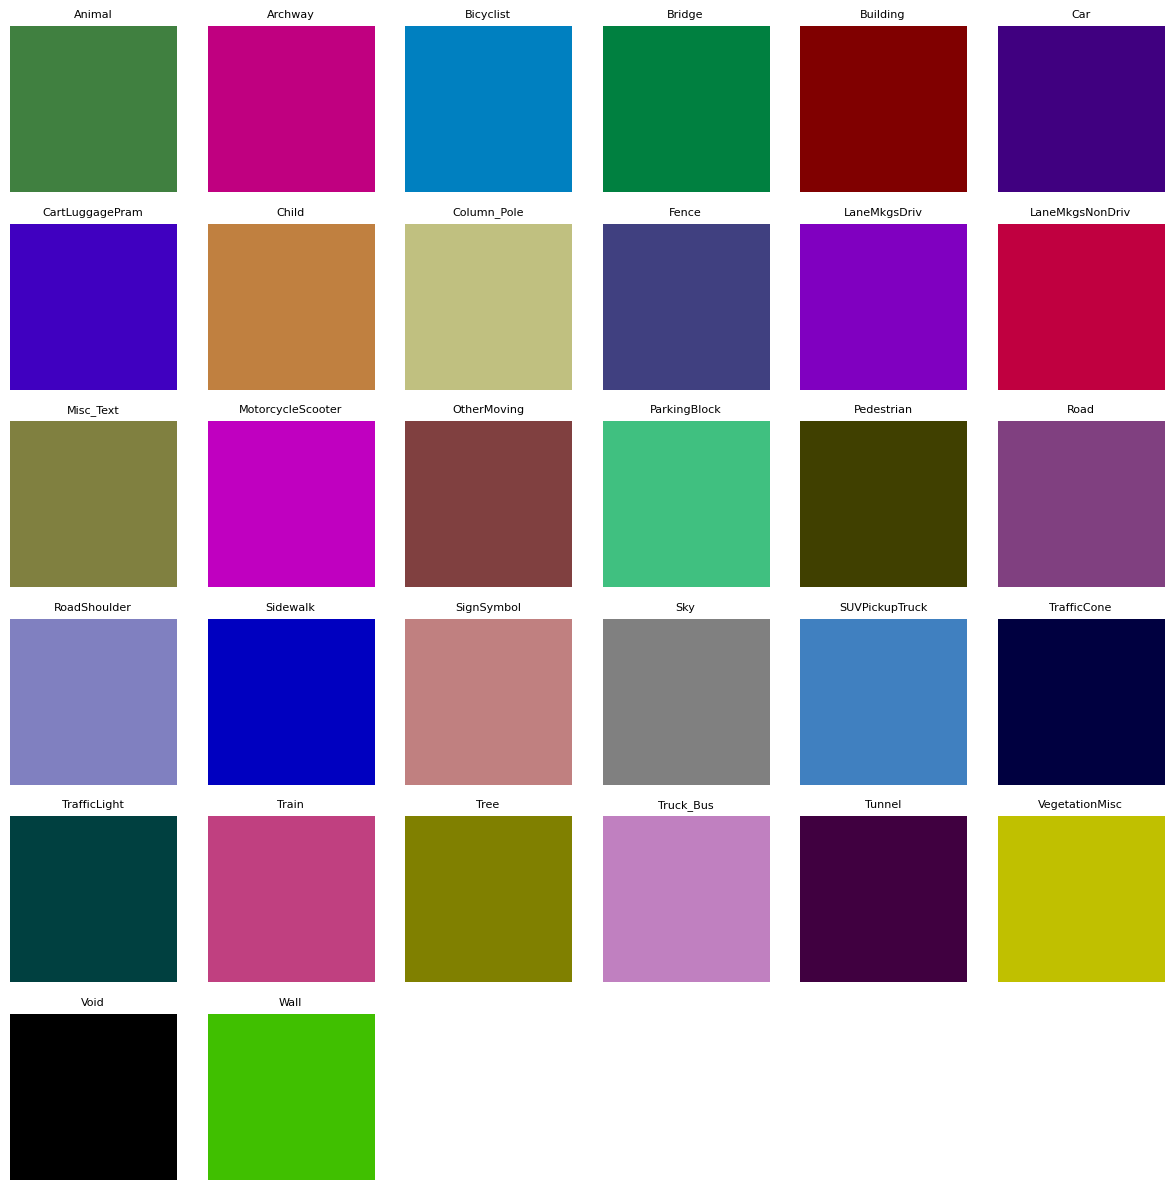

In [77]:
test_output(test_dataset)
visualize_all_classes(class_dict)
# print(f"Тип данных: {img.dtype}, min: {img.min()}, max: {img.max()}")

# Модель

In [78]:
model = smp.DeepLabV3Plus(
    encoder_name=encoder,
    encoder_weights=enc_weights,
    in_channels=3,
    classes=NUM_CLASSES,
).to(device)

In [79]:
class_counts = np.zeros(NUM_CLASSES)
for _, mask in train_dataset:
    mask = mask.numpy()
    for cls in range(NUM_CLASSES):
        class_counts[cls] += np.sum(mask == cls)

total_pixels = np.sum(class_counts)
total_pixels

libpng warning: iCCP: known incorrect sRGB profile


np.float64(96731136.0)

In [ ]:
class_weights = total_pixels / (NUM_CLASSES * class_counts + 1e-6)
for cls in rare_classes:  # Bridge, CartLuggagePram, Column_Pole, LaneMkgsNonDriv, ParkingBlock, RoadShoulder, SUVPickupTruck
    class_weights[cls] *= 2  # увеличение веса в 2 раза
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
class_weights = class_weights / class_weights.max()




focal_loss = FocalLoss(mode="multiclass", gamma=2.0)
criterion = nn.CrossEntropyLoss(weight=class_weights)
dice_loss = DiceLoss(mode="multiclass", classes=32)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5, verbose=True)

/Users/xd/Desktop/nsu_2course/2_sem/AI/venv/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [84]:
best_val_loss = float("inf")

counter = 0
best_iou = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        # fc_loss = focal_loss(outputs, masks)
        fc_loss = focal_loss(outputs.cpu(), masks.cpu())
        dc_loss = dice_loss(outputs, masks)
        loss = 0.7 * fc_loss + 0.3 * dc_loss
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # print(f"Epoch {epoch+1}, Train Loss: {train_loss / len(train_loader)}")
    
    # Валидация
    model.eval()
    val_loss = 0
    val_iou = 0
    val_pixel_acc = 0
    val_dice = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            # loss = criterion(outputs, masks)
            # fc_loss = focal_loss(outputs, masks)
            fc_loss = focal_loss(outputs.cpu(), masks.cpu())
            dc_loss = dice_loss(outputs, masks)
            loss = 0.7 * fc_loss + 0.3 * dc_loss
            val_loss += loss.item()
            
            # IoU
            iou, _ = compute_iou(outputs, masks, NUM_CLASSES, ignore_classes=[30])
            val_iou += iou
            
            #   Pixel accuracy
            pixel_acc = compute_pixel_accuracy(outputs, masks)
            val_pixel_acc += pixel_acc

            #   Dice
            dice, _ = compute_dice(outputs, masks, NUM_CLASSES, ignore_classes=[30])
            val_dice += dice
    
    val_loss = val_loss / len(val_loader)
    val_iou = val_iou / len(val_loader)
    val_pixel_acc = val_pixel_acc / len(val_loader)
    val_dice = val_dice / len(val_loader)
    print(f"Epoch: {epoch+1}/{num_epochs}")
    print(f"\tTrain Loss: {train_loss / len(train_loader):.4f}, Val Loss: {val_loss:.4f}\n\tVal IoU: {val_iou:.4f}\n\tVal Dice: {val_dice:.4f}\n\tVal PA: {val_pixel_acc:.4f}")
    scheduler.step(val_loss)

    # Сохранение лучшей модели по IoU
    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), "best_model_nm.pth")
        print(f"Сохранена модель с IoU: {best_iou}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early Stopping сработал")
            break

libpng warning: iCCP: known incorrect sRGB profile


Epoch: 1/50
	Train Loss: 0.4648, Val Loss: 0.3514
	Val IoU: 0.5288
	Val Dice: 0.5553
	Val PA: 0.8112
Сохранена модель с IoU: 0.5288463569984068


libpng warning: iCCP: known incorrect sRGB profile


Epoch: 2/50
	Train Loss: 0.4207, Val Loss: 0.3295
	Val IoU: 0.5293
	Val Dice: 0.5586
	Val PA: 0.8268
Сохранена модель с IoU: 0.5292902459842734


libpng warning: iCCP: known incorrect sRGB profile


...

Epoch: 48/50
	Train Loss: 0.2100, Val Loss: 0.2141
	Val IoU: 0.6406
	Val Dice: 0.6922
	Val PA: 0.8978


libpng warning: iCCP: known incorrect sRGB profile


Epoch: 49/50
	Train Loss: 0.2162, Val Loss: 0.2060
	Val IoU: 0.6507
	Val Dice: 0.7034
	Val PA: 0.9026
Сохранена модель с IoU: 0.6507069844065946


libpng warning: iCCP: known incorrect sRGB profile


Epoch: 50/50
	Train Loss: 0.2036, Val Loss: 0.2081
	Val IoU: 0.6509
	Val Dice: 0.7032
	Val PA: 0.9000
Сохранена модель с IoU: 0.6508614767125362


In [33]:
model.load_state_dict(torch.load("best_model_nm.pth"))

<All keys matched successfully>

# METRICS

## IOU, Dice, Pixel accuracy

In [ ]:
test_ious = []
test_pixel_accs = []
test_dices = []
class_iou_sums = np.zeros(NUM_CLASSES)
class_dice_sums = np.zeros(NUM_CLASSES)
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)

        #   IoU
        mean_iou, class_ious = compute_iou(outputs, masks, NUM_CLASSES, ignore_classes=[30])
        test_ious.append(mean_iou)

        # Pixel accuracy
        pixel_acc = compute_pixel_accuracy(outputs, masks)
        test_pixel_accs.append(pixel_acc)

        #   Dice
        mean_dice, class_dices = compute_dice(outputs, masks, NUM_CLASSES, ignore_classes=[30])
        test_dices.append(mean_dice)

        # IoU и Dice стакаются по классам с учетом исключенного класса
        cls_idx = 0
        for cls in range(NUM_CLASSES):
            if cls not in [30]:  # пример для пропуска класса (надо ли вообще пропускать классы?) тут для void сделал
                class_iou_sums[cls] += class_ious[cls_idx]
                class_dice_sums[cls] += class_dices[cls_idx]
                cls_idx += 1


print(f"(NO VOID) Mean IoU: {np.mean(test_ious):.4f}, Mean Dice: {np.mean(test_ious):.4f}, Mean Pixel Accuracy: {np.mean(test_pixel_accs):.4f}")
print("IoU, Dice по классам (without Void):")
for cls in range(NUM_CLASSES):
    if cls not in [30]:
        print(f"Class {cls} ({class_dict.iloc[cls]['name']}): {class_iou_sums[cls] / len(test_loader):.4f}, Dice: {class_dice_sums[cls] / len(test_loader):.4f}")




(NO VOID) Mean IoU: 0.6093, Mean Dice: 0.6093, Mean Pixel Accuracy: 0.8765
IoU, Dice по классам (without Void):
Class 0 (Animal): 0.2586, Dice: 0.2586
Class 1 (Archway): 0.7644, Dice: 0.7758
Class 2 (Bicyclist): 0.4521, Dice: 0.5152
Class 3 (Bridge): 0.9472, Dice: 0.9507
Class 4 (Building): 0.7545, Dice: 0.8367
Class 5 (Car): 0.6818, Dice: 0.7854
Class 6 (CartLuggagePram): 0.3103, Dice: 0.3103
Class 7 (Child): 0.7933, Dice: 0.8097
Class 8 (Column_Pole): 0.1248, Dice: 0.2125
Class 9 (Fence): 0.4811, Dice: 0.5312
Class 10 (LaneMkgsDriv): 0.5220, Dice: 0.6795
Class 11 (LaneMkgsNonDriv): 0.9483, Dice: 0.9483
Class 12 (Misc_Text): 0.2887, Dice: 0.3902
Class 13 (MotorcycleScooter): 0.9828, Dice: 0.9828
Class 14 (OtherMoving): 0.2206, Dice: 0.2782
Class 15 (ParkingBlock): 0.5614, Dice: 0.6029
Class 16 (Pedestrian): 0.3284, Dice: 0.4656
Class 17 (Road): 0.9116, Dice: 0.9530
Class 18 (RoadShoulder): 0.8113, Dice: 0.8184
Class 19 (Sidewalk): 0.7149, Dice: 0.8042
Class 20 (SignSymbol): 0.3395, Di

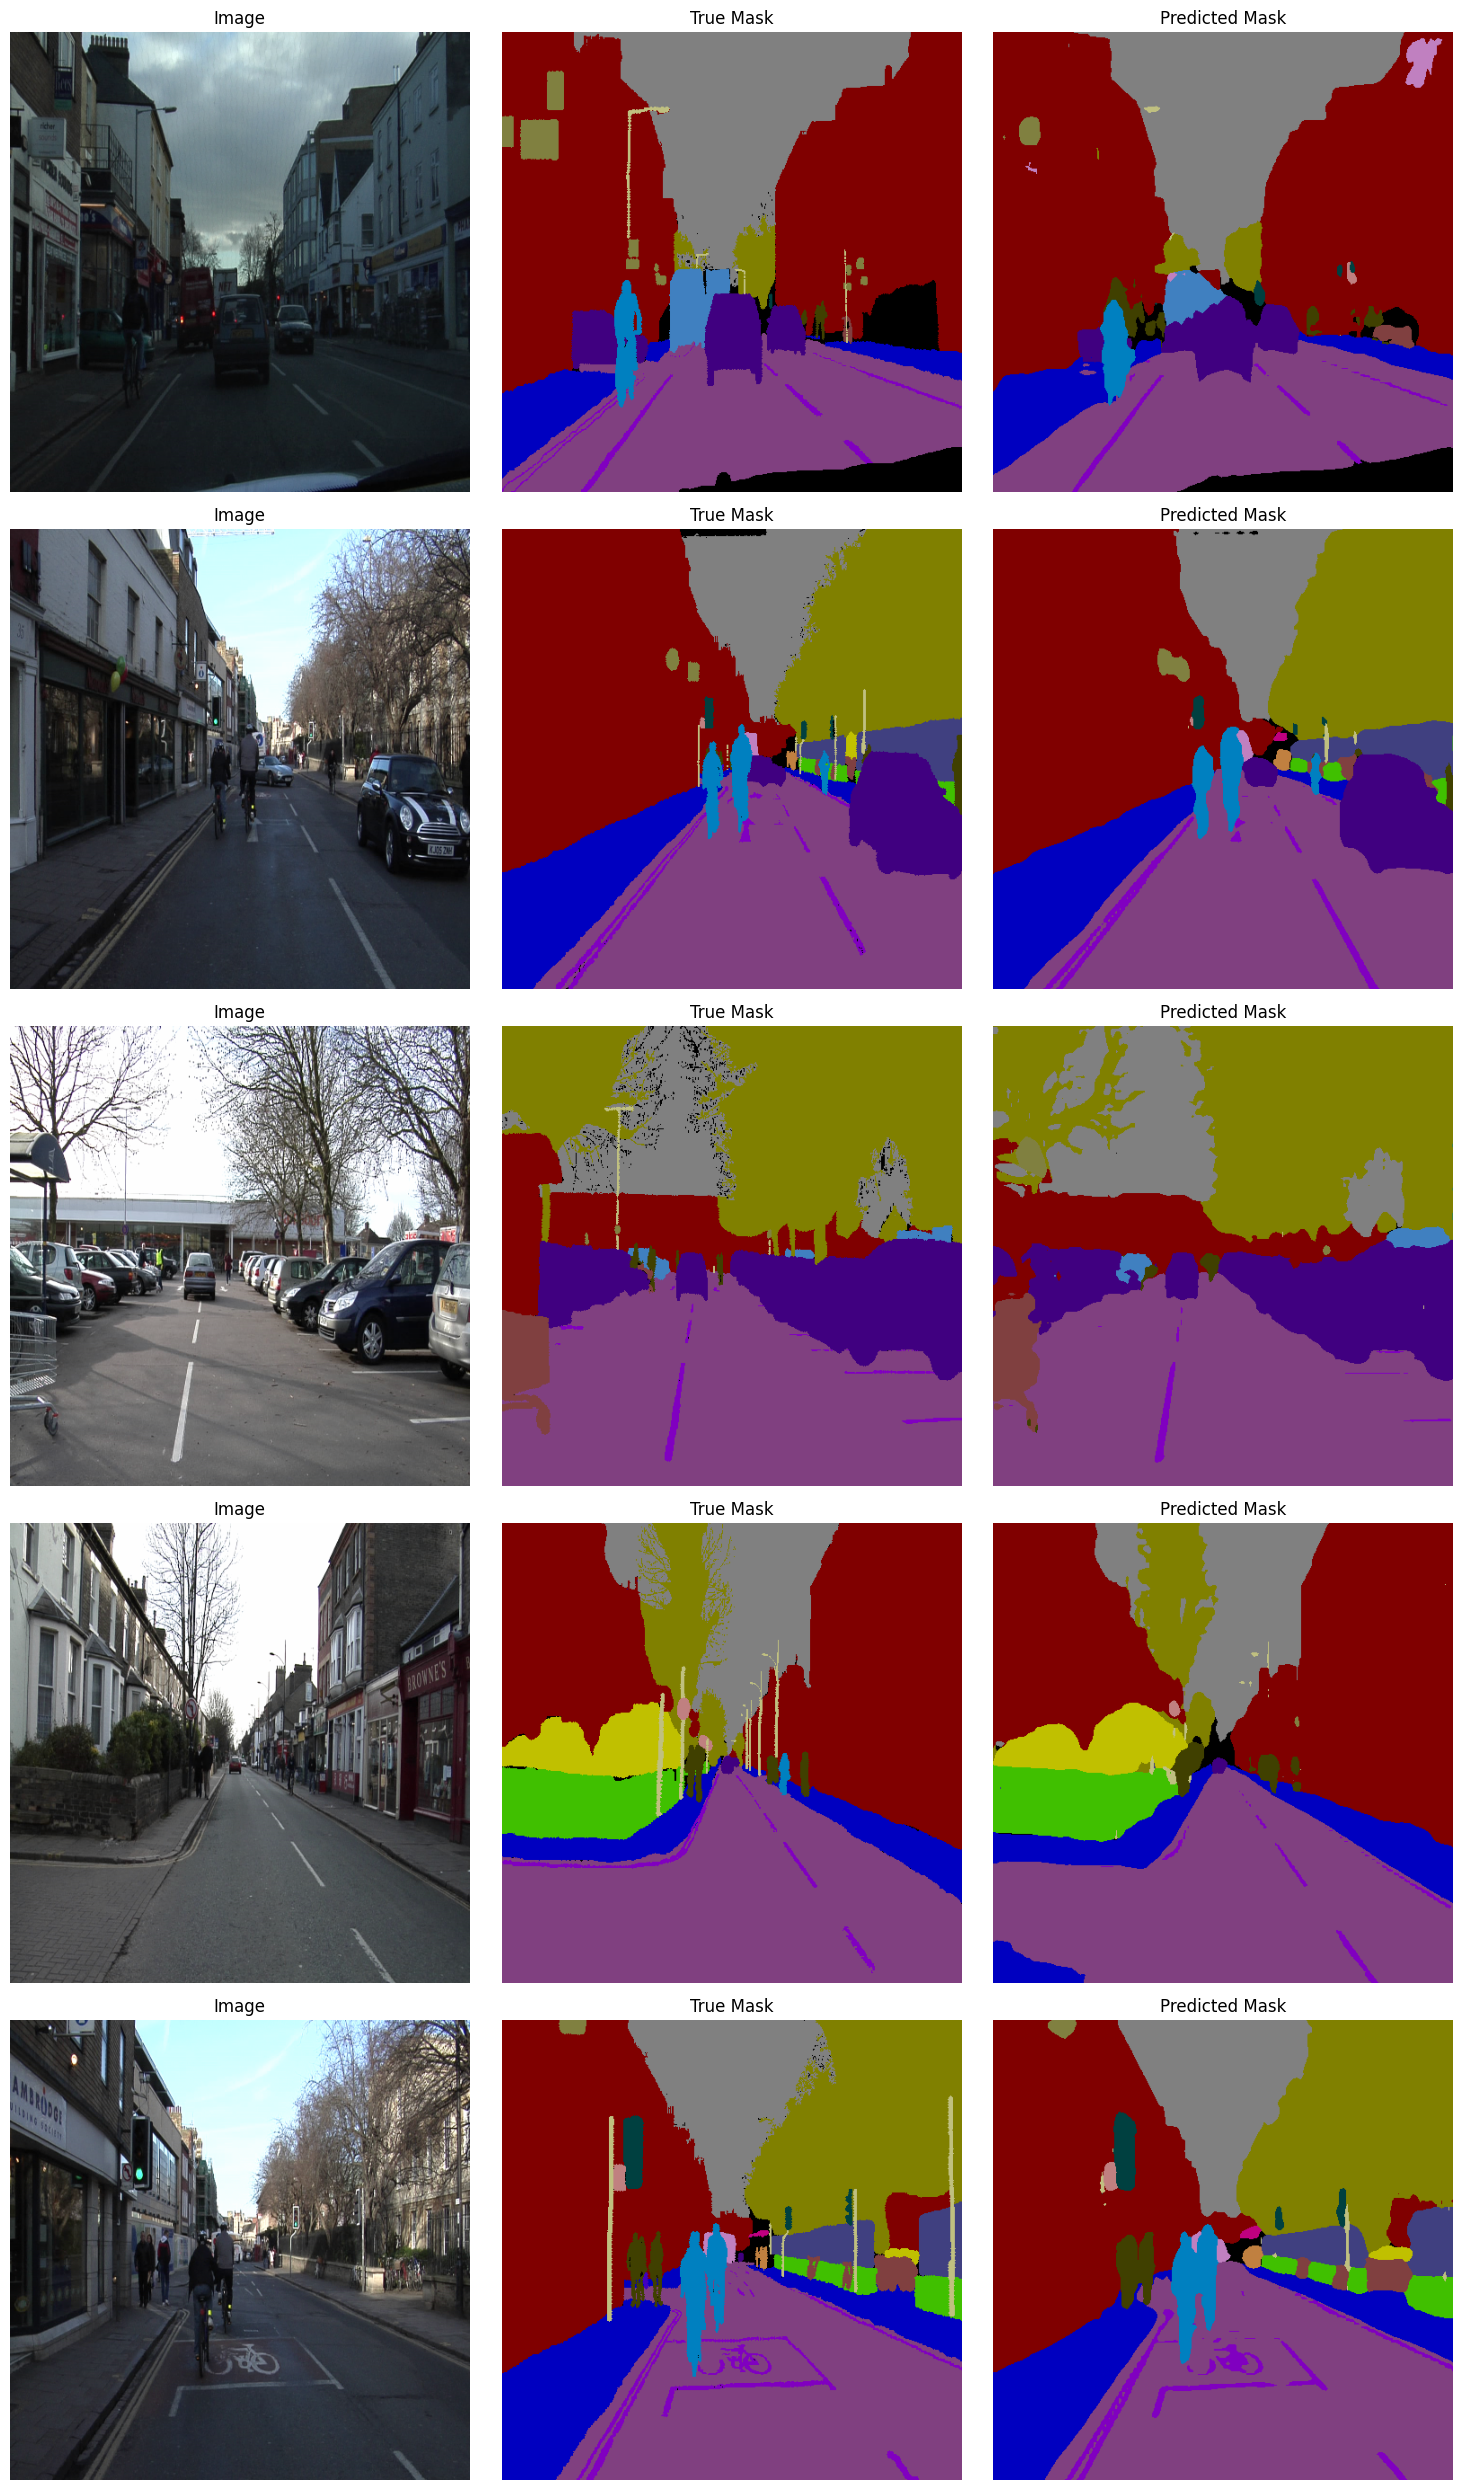

In [86]:
# Визуализация 5 случайных примеров
num_examples = 5
random_indices = random.sample(range(len(test_dataset)), num_examples)  # Случайные индексы


plt.figure(figsize=(15, 5 * num_examples))

model.eval()
with torch.no_grad():
    for i, idx in enumerate(random_indices):
        # Получаем изображение и маску
        img, true_mask = test_dataset[idx]
        img = img.unsqueeze(0).to(device)  # Добавляем batch dimension и переносим на устройство
        true_mask = true_mask  # Уже в формате (H, W)

        # Получаем предсказание
        output = model(img)
        pred_mask = output.argmax(dim=1).squeeze().cpu()  # (H, W)

        # Денормализация и преобразование масок
        img_denorm, true_mask_rgb, pred_mask_rgb = visualize_triplet(
            img.squeeze(), true_mask, pred_mask, class_dict, mean, std
        )

        # Визуализация
        plt.subplot(num_examples, 3, i * 3 + 1)
        plt.imshow(img_denorm)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(num_examples, 3, i * 3 + 2)
        plt.imshow(true_mask_rgb)
        plt.title("True Mask")
        plt.axis("off")

        plt.subplot(num_examples, 3, i * 3 + 3)
        plt.imshow(pred_mask_rgb)
        plt.title("Predicted Mask")
        plt.axis("off")

plt.tight_layout()
plt.show()